In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

In [4]:
#posicion y velocidad de Apophis
tabla, jd, X = pc.consulta_horizons(id="Apophis",epochs="2026-04-20",location="@SSB")
#X: vector de estado (posicion y velocidad) en SI
print(X)

[-4.54615645e+10  1.46498906e+11 -8.91205586e+09 -2.72244445e+04
 -4.00763765e+03 -4.30333986e+02]


Para la determinacion de los elementos orbitales se necesitan estos vectores r, v, h, n y e

In [7]:
rvec = X[:3] #posicion
r = np.linalg.norm(rvec) #magnitud de la posicion
vvec = X[3:] #velocidad
v = np.linalg.norm(vvec) #magnitud de la velocidad

hvec = np.cross(rvec,vvec) #vector momento angular
h = np.linalg.norm(hvec) #magnitud del momento angular

In [8]:
#Aprox, mu = mu del sol
mu = pc.constantes.mu_sun
evec = np.cross(vvec,hvec)/mu - rvec/r #vector excentricidad

nvec = np.cross([0,0,1],hvec) #vector nodo
n = np.linalg.norm(nvec) #magnitud del nodo

Ahora a determinar los elementos orbitales p, e, I, Omega, omega y f

In [19]:
def orbital_elements_from_state(rvec, vvec, mu):
    """
    Compute classical orbital elements from state vectors.

    Parameters
    ----------
    rvec : array-like, shape (3,)
        Position vector.
    vvec : array-like, shape (3,)
        Velocity vector.
    mu : float
        Standard gravitational parameter of the central body.

    Returns
    -------
    p : float
        Semi-latus rectum.
    e : float
        Eccentricity magnitude.
    I : float
        Inclination (rad).
    Omega : float
        Longitude of ascending node (rad).
    omega : float
        Argument of periapsis (rad).
    f : float
        True anomaly (rad).
    """
    rvec = np.asarray(rvec, dtype=float)
    vvec = np.asarray(vvec, dtype=float)

    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)

    nvec = np.cross([0.0, 0.0, 1.0], hvec)
    n = np.linalg.norm(nvec)

    p = h**2 / mu
    I = np.arccos(np.clip(hvec[2] / h, -1.0, 1.0))

    # Handle near-equatorial / near-circular edge cases safely.
    if n > 0 and e > 0:
        omega_p = np.arccos(np.clip(np.dot(nvec, evec) / (n * e), -1.0, 1.0))
        omega = 2 * np.pi - omega_p if evec[2] < 0 else omega_p

        Omega_p = np.arccos(np.clip(np.dot([1.0, 0.0, 0.0], nvec) / n, -1.0, 1.0))
        Omega = 2 * np.pi - Omega_p if nvec[1] < 0 else Omega_p
    else:
        omega = 0.0
        Omega = 0.0

    if e > 0:
        f_p = np.arccos(np.clip(np.dot(evec, rvec) / (e * r), -1.0, 1.0))
        f = 2 * np.pi - f_p if np.dot(rvec, vvec) / r < 0 else f_p
    else:
        f = 0.0

    return p, e, I, Omega, omega, f


p, e, I, Omega, omega, f = orbital_elements_from_state(rvec, vvec, mu)

rad = 180 / np.pi
print(f"p: {p}")
print(f"e: {e}")
print(f"inclinacion: {I * rad} grados")
print(f"longitud del nodo ascendente: {Omega * rad} grados")
print(f"argumento del periastro: {omega * rad} grados")
print(f"anomalia verdadera: {f * rad} grados")

p: 131509557547.50772
e: 0.19681731768435504
inclinacion: 3.3475799477925516 grados
longitud del nodo ascendente: 203.8811521637987 grados
argumento del periastro: 126.30633780951213 grados
anomalia verdadera: 137.0639111789069 grados


In [ ]:
#elementos orbitales del Sol
tabla, jds, Xs = pc.consulta_horizons(id="Sun",epochs=dict(start="2026-04-20",stop="2038-04-20",step="180d"),location="@SSB")
#X: vector de estado (posicion y velocidad) en SI

               x             y             z         vx         vy        vz
0  -3.440632e+08 -8.162708e+08  1.742946e+07  11.877114   2.170084 -0.243330
1  -1.718684e+08 -7.628401e+08  1.385175e+07  10.399007   4.558005 -0.224020
2  -2.552545e+07 -6.716062e+08  1.064029e+07   8.181584   6.842898 -0.186921
3   8.431758e+07 -5.536674e+08  7.987440e+06   5.818850   8.230228 -0.143695
4   1.561933e+08 -4.179335e+08  6.049654e+06   3.234004   9.229553 -0.100161
5   1.845312e+08 -2.754393e+08  4.929415e+06   0.661803   9.111716 -0.051870
6   1.731440e+08 -1.352396e+08  4.655875e+06  -2.050663   8.671100  0.004320
7   1.211793e+08 -8.664641e+06  5.191260e+06  -4.499918   7.344613  0.061774
8   3.687541e+07  9.509637e+07  6.465879e+06  -6.542314   5.884230  0.109305
9  -7.703503e+07  1.674886e+08  8.393896e+06  -7.960189   3.535688  0.142152
10 -2.087529e+08  2.026156e+08  1.083689e+07  -8.835437   1.051223  0.163215
11 -3.513466e+08  1.956867e+08  1.357195e+07  -9.101427  -2.043595  0.175954

In [26]:
Xs = np.array(Xs)

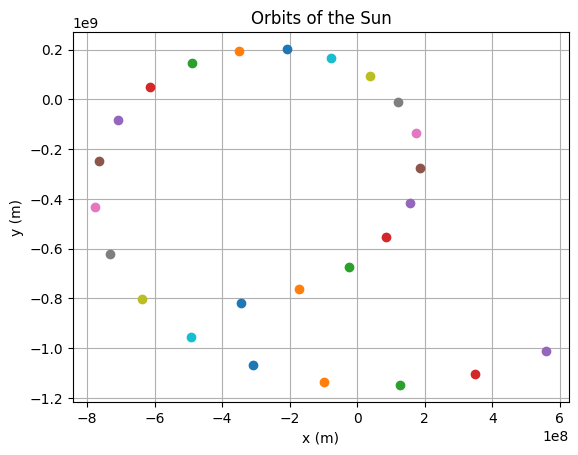

In [32]:
mu = pc.constantes.mu_sun + pc.constantes.mu_jupiter + pc.constantes.mu_saturn
Es = np.zeros((len(jds), 6))
for i, jd in enumerate(jds):
    rvec = Xs[i,:3]
    vvec = Xs[i,3:]
    p, e, I, Omega, omega, f = orbital_elements_from_state(rvec, vvec, mu)
    plt.plot(rvec[0], rvec[1], 'o')
    Es[i] = [p, e, I, Omega, omega, f]
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Orbits of the Sun')
plt.grid(True)
plt.show()


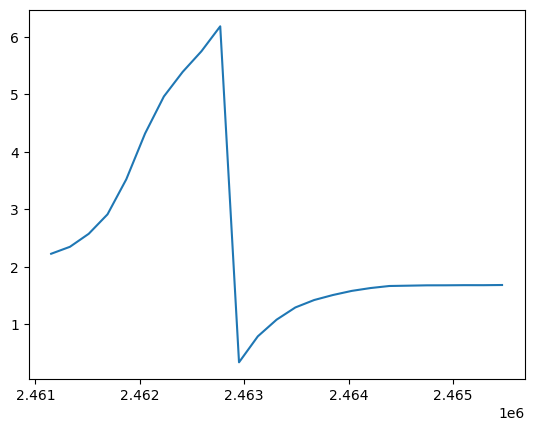

In [34]:
plt.plot(jds, Es[:,3], label='p')